МАТРИЦЫ ЭКСПЕРТНЫХ ПРЕДПОЧТЕНИЙ
P1:
[[0.  0.8 0.3 0. ]
 [0.9 0.  0.  0.8]
 [0.  0.  0.  0. ]
 [0.9 0.  1.  0. ]]
P2:
[[0.  0.6 0.5 0. ]
 [0.7 0.  0.  0.9]
 [0.  0.  0.  0. ]
 [0.  0.  0.6 0. ]]
P3:
[[0.  0.4 0.4 0. ]
 [0.8 0.  0.  0.4]
 [1.  0.  0.  0. ]
 [0.  0.  0.5 0. ]]

1.1. МАТРИЦА СУММАРНОГО ОТНОШЕНИЯ
PΣ = (P1 + P2 + P3) / 3

PΣ =
[[0.    0.6   0.4   0.   ]
 [0.8   0.    0.    0.7  ]
 [0.333 0.    0.    0.   ]
 [0.3   0.    0.7   0.   ]]

1.2. АГРЕГИРОВАННОЕ ОТНОШЕНИЕ СТРОГОГО ПОРЯДКА
ШАГ 1: Имеем PΣ

ШАГ 2: Строим орграф GΣ
Матрица смежности RΣ:
[[0 1 1 0]
 [1 0 0 1]
 [1 0 0 0]
 [1 0 1 0]]

ШАГ 3: Разрушение контуров
Найдено циклов: 4
Итерация 1: удалены ['a4→a1'] (вес 0.300)
Итерация 2: удалены ['a3→a1'] (вес 0.333)
Итерация 3: удалены ['a1→a2'] (вес 0.600)

Матрица после разрушения контуров:
P =
[[0.  0.  0.4 0. ]
 [0.8 0.  0.  0.7]
 [0.  0.  0.  0. ]
 [0.  0.  0.7 0. ]]

ШАГ 4: Транзитивное замыкание
Агрегированное отношение строгого порядка:
[[0.  0.  0.4 0. ]
 [0.8 0.  0.7

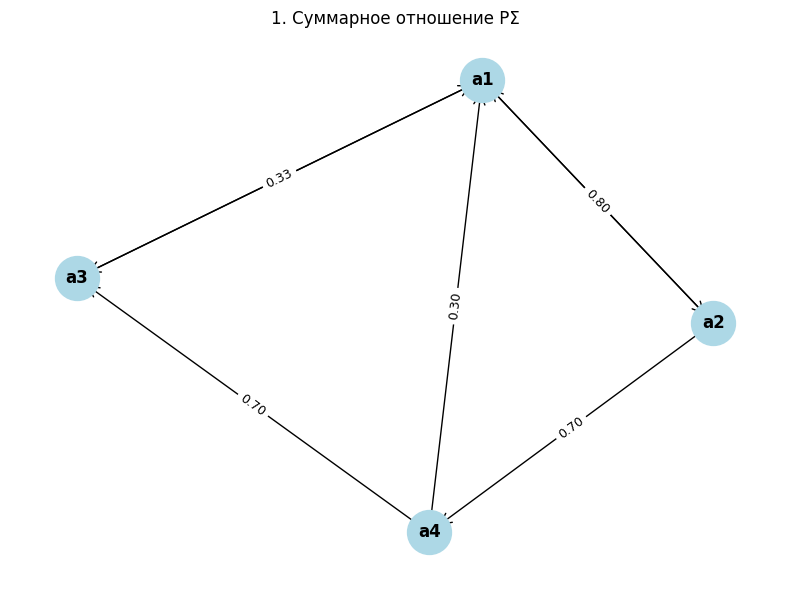

Создан: 1_P_sum.png


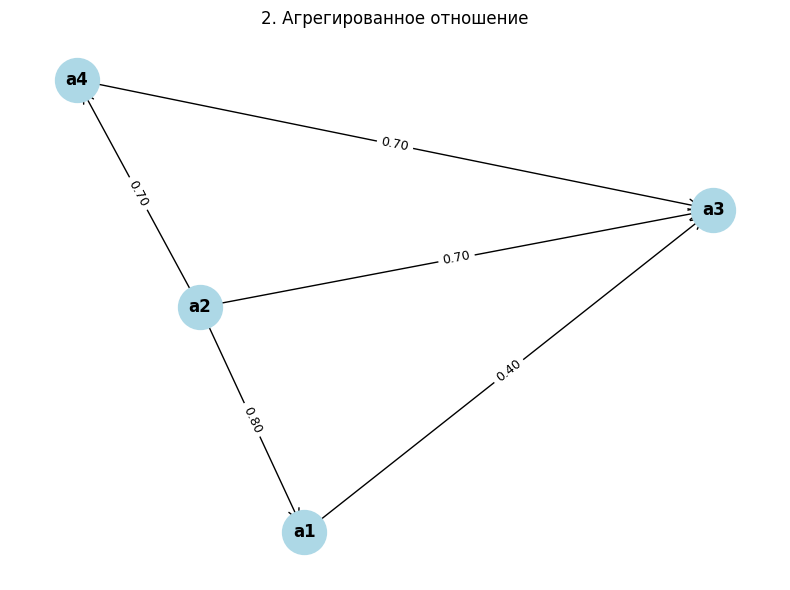

Создан: 2_aggregated.png


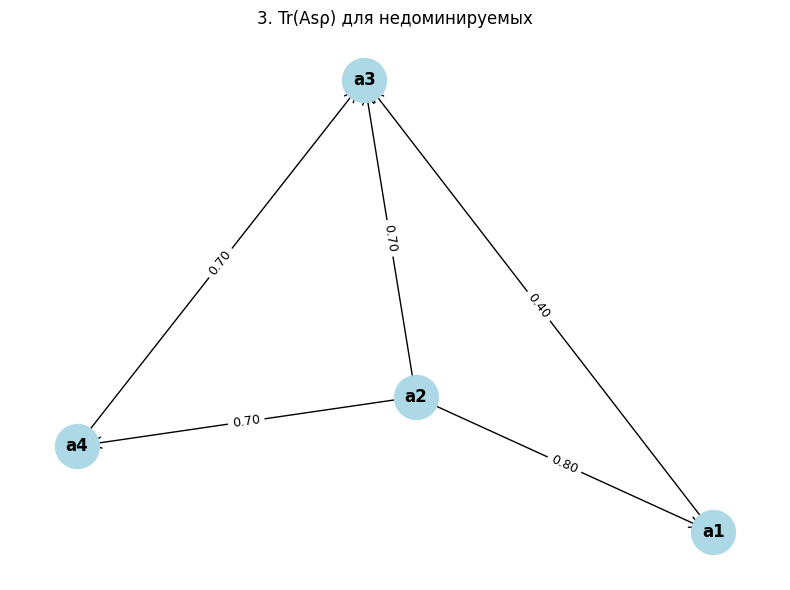

Создан: 3_tr_asym.png

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
1.1. PΣ:
[[0.    0.6   0.4   0.   ]
 [0.8   0.    0.    0.7  ]
 [0.333 0.    0.    0.   ]
 [0.3   0.    0.7   0.   ]]

1.2. Агрегированное отношение:
[[0.  0.  0.4 0. ]
 [0.8 0.  0.7 0.7]
 [0.  0.  0.  0. ]
 [0.  0.  0.7 0. ]]

1.3. Суммарные расстояния: 1.6067 (от PΣ), 4.7600 (от P_agg)

1.4. Недоминируемые альтернативы в Tr(Asρ): ['a2']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# =============================================================================
# МАТРИЦЫ ЭКСПЕРТНЫХ ПРЕДПОЧТЕНИЙ
# =============================================================================
P1 = np.array([[0, 0.8, 0.3, 0], [0.9, 0, 0, 0.8], [0, 0, 0, 0], [0.9, 0, 1, 0]])
P2 = np.array([[0, 0.6, 0.5, 0], [0.7, 0, 0, 0.9], [0, 0, 0, 0], [0, 0, 0.6, 0]])
P3 = np.array([[0, 0.4, 0.4, 0], [0.8, 0, 0, 0.4], [1, 0, 0, 0], [0, 0, 0.5, 0]])

print("МАТРИЦЫ ЭКСПЕРТНЫХ ПРЕДПОЧТЕНИЙ")
print("P1:"); print(P1)
print("P2:"); print(P2)
print("P3:"); print(P3)

# =============================================================================
# 1.1. МАТРИЦА СУММАРНОГО ОТНОШЕНИЯ
# =============================================================================
print("\n" + "="*50)
print("1.1. МАТРИЦА СУММАРНОГО ОТНОШЕНИЯ")
print("="*50)

P_sum = (P1 + P2 + P3) / 3
print("PΣ = (P1 + P2 + P3) / 3")
print("\nPΣ =")
print(np.round(P_sum, 3))

# =============================================================================
# 1.2. АГРЕГИРОВАННОЕ ОТНОШЕНИЕ СТРОГОГО ПОРЯДКА
# =============================================================================
print("\n" + "="*50)
print("1.2. АГРЕГИРОВАННОЕ ОТНОШЕНИЕ СТРОГОГО ПОРЯДКА")
print("="*50)

# Алгоритм из лекции стр. 13-14
print("ШАГ 1: Имеем PΣ")

print("\nШАГ 2: Строим орграф GΣ")
R_sum = (P_sum > 0).astype(int)
print("Матрица смежности RΣ:")
print(R_sum)

print("\nШАГ 3: Разрушение контуров")
# Находим и выводим все циклы
G = nx.DiGraph()
for i in range(4):
    for j in range(4):
        if R_sum[i,j] == 1:
            G.add_edge(i, j, weight=P_sum[i,j])

cycles = list(nx.simple_cycles(G))
print(f"Найдено циклов: {len(cycles)}")

# Разрушаем циклы удалением минимальных дуг
P_temp = P_sum.copy()
R_temp = R_sum.copy()

iteration = 1
while cycles:
    # Находим минимальный вес в циклах
    min_weight = min(P_temp[i,j] for cycle in cycles
                    for i,j in [(cycle[k], cycle[(k+1)%len(cycle)])
                               for k in range(len(cycle))])

    # Удаляем дуги с минимальным весом
    removed = []
    for i in range(4):
        for j in range(4):
            if abs(P_temp[i,j] - min_weight) < 1e-6:
                P_temp[i,j] = 0
                R_temp[i,j] = 0
                removed.append(f"a{i+1}→a{j+1}")

    print(f"Итерация {iteration}: удалены {removed} (вес {min_weight:.3f})")

    # Обновляем граф
    G = nx.DiGraph()
    for i in range(4):
        for j in range(4):
            if R_temp[i,j] == 1:
                G.add_edge(i, j)
    cycles = list(nx.simple_cycles(G))
    iteration += 1

P_no_cycles = P_temp
print("\nМатрица после разрушения контуров:")
print("P =")
print(np.round(P_no_cycles, 3))

print("\nШАГ 4: Транзитивное замыкание")
# Формула Уоршалла для нечетких отношений
P_trans = P_no_cycles.copy()
for k in range(4):
    for i in range(4):
        for j in range(4):
            P_trans[i,j] = max(P_trans[i,j], min(P_trans[i,k], P_trans[k,j]))

P_aggregated = P_trans
print("Агрегированное отношение строгого порядка:")
print(np.round(P_aggregated, 3))

# =============================================================================
# 1.3. СУММАРНЫЕ РАССТОЯНИЯ
# =============================================================================
print("\n" + "="*50)
print("1.3. СУММАРНЫЕ РАССТОЯНИЯ")
print("="*50)

def calculate_distance(P1, P2):
    return np.sum((P1 - P2) ** 2)

# Расстояния от суммарного отношения
d1_sum = calculate_distance(P_sum, P1)
d2_sum = calculate_distance(P_sum, P2)
d3_sum = calculate_distance(P_sum, P3)
total_sum = d1_sum + d2_sum + d3_sum

print("От суммарного отношения:")
print(f"d(PΣ, P1) = {d1_sum:.4f}")
print(f"d(PΣ, P2) = {d2_sum:.4f}")
print(f"d(PΣ, P3) = {d3_sum:.4f}")
print(f"Сумма: {total_sum:.4f}")

# Расстояния от агрегированного отношения
d1_agg = calculate_distance(P_aggregated, P1)
d2_agg = calculate_distance(P_aggregated, P2)
d3_agg = calculate_distance(P_aggregated, P3)
total_agg = d1_agg + d2_agg + d3_agg

print("\nОт агрегированного отношения:")
print(f"d(P_agg, P1) = {d1_agg:.4f}")
print(f"d(P_agg, P2) = {d2_agg:.4f}")
print(f"d(P_agg, P3) = {d3_agg:.4f}")
print(f"Сумма: {total_agg:.4f}")

# =============================================================================
# 1.4. НЕДОМИНИРУЕМЫЕ АЛЬТЕРНАТИВЫ ДЛЯ Tr(Asρ)
# =============================================================================
print("\n" + "="*50)
print("1.4. НЕДОМИНИРУЕМЫЕ АЛЬТЕРНАТИВЫ ДЛЯ Tr(Asρ)")
print("="*50)

print("ШАГ 1: Вычисляем Asρ для агрегированного отношения")
# Формула со стр. 19: μ_Asρ(a_i,a_j) = max(μ_ρ(a_i,a_j) - μ_ρ(a_j,a_i), 0)
P_asym = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        if i != j:
            P_asym[i,j] = max(P_aggregated[i,j] - P_aggregated[j,i], 0)

print("Asρ =")
print(np.round(P_asym, 3))

print("\nШАГ 2: Вычисляем Tr(Asρ)")
P_tr_asym = P_asym.copy()
for k in range(4):
    for i in range(4):
        for j in range(4):
            P_tr_asym[i,j] = max(P_tr_asym[i,j], min(P_tr_asym[i,k], P_tr_asym[k,j]))

print("Tr(Asρ) =")
print(np.round(P_tr_asym, 3))

print("\nШАГ 3: Ищем недоминируемые альтернативы")
# Альтернатива недоминируема, если в нее не входят дуги из других вершин
non_dominated = []
for j in range(4):
    has_incoming = False
    for i in range(4):
        if i != j and P_tr_asym[i,j] > 0:
            has_incoming = True
            break
    if not has_incoming:
        non_dominated.append(j)
        print(f"a{j+1}: нет входящих дуг → НЕДОМИНИРУЕМАЯ")
    else:
        print(f"a{j+1}: есть входящие дуги → доминируемая")

print(f"\nНедоминируемые альтернативы: {[f'a{i+1}' for i in non_dominated]}")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ")
print("="*50)

def draw_graph(P, title, filename):
    G = nx.DiGraph()

    for i in range(4):
        G.add_node(f'a{i+1}')
        for j in range(4):
            if P[i,j] > 0:
                G.add_edge(f'a{i+1}', f'a{j+1}', weight=P[i,j])

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)

    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Создан: {filename}")

draw_graph(P_sum, "1. Суммарное отношение PΣ", "1_P_sum.png")
draw_graph(P_aggregated, "2. Агрегированное отношение", "2_aggregated.png")
draw_graph(P_tr_asym, "3. Tr(Asρ) для недоминируемых", "3_tr_asym.png")

# =============================================================================
# ИТОГИ
# =============================================================================
print("\n" + "="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print("1.1. PΣ:"); print(np.round(P_sum, 3))
print("\n1.2. Агрегированное отношение:"); print(np.round(P_aggregated, 3))
print(f"\n1.3. Суммарные расстояния: {total_sum:.4f} (от PΣ), {total_agg:.4f} (от P_agg)")
print(f"\n1.4. Недоминируемые альтернативы в Tr(Asρ): {[f'a{i+1}' for i in non_dominated]}")